In [24]:
import numpy as np
import torch
import pandas as pd
from torchvision.datasets import ImageFolder

In [25]:
import os

print(os.getcwd())

/home/rahul/Projects/deep-learning-projects/dog-vs-cat-cnn/notebook


In [26]:
import os

print(os.listdir(".."))

['data', 'notebook', 'readme.md']


In [27]:
train_dataset = ImageFolder("../data/train")
test_dataset = ImageFolder("../data/test")

In [28]:
train_dataset.class_to_idx

{'cats': 0, 'dogs': 1}

In [29]:
test_dataset.class_to_idx

{'cats': 0, 'dogs': 1}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2885156].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8036647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.541961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Cli

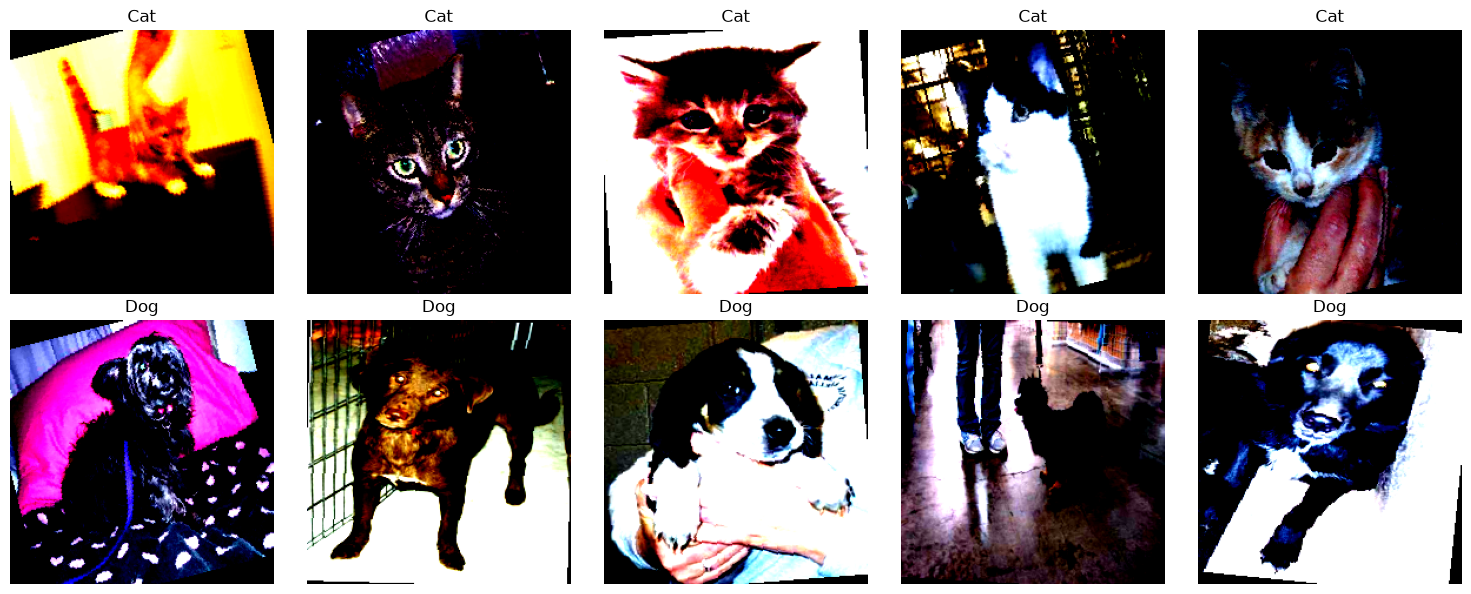

In [53]:
import matplotlib.pyplot as plt

# Find indices of cats and dogs
cat_indices = []
dog_indices = []

for i, (_, label) in enumerate(train_dataset):
    if label == 0 and len(cat_indices) < 5:
        cat_indices.append(i)
    elif label == 1 and len(dog_indices) < 5:
        dog_indices.append(i)

    if len(cat_indices) == 5 and len(dog_indices) == 5:
        break

# Plot images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# First row: Cats
for j, idx in enumerate(cat_indices):
    image, label = train_dataset[idx]
    image = image.permute(1, 2, 0)  # CHW -> HWC

    axes[0, j].imshow(image)
    axes[0, j].set_title("Cat")
    axes[0, j].axis("off")

# Second row: Dogs
for j, idx in enumerate(dog_indices):
    image, label = train_dataset[idx]
    image = image.permute(1, 2, 0)

    axes[1, j].imshow(image)
    axes[1, j].set_title("Dog")
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

In [30]:
'''
transformations to be applied on data:
1. reshaping every image to (224, 224)
2. data augmentation->flips, rotations, zoom in/out etc...
3. convert images to pytorch tensors
4. normalize the tensors
'''

'\ntransformations to be applied on data:\n1. reshaping every image to (224, 224)\n2. data augmentation->flips, rotations, zoom in/out etc...\n3. convert images to pytorch tensors\n4. normalize the tensors\n'

In [31]:
from torchvision.transforms import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [32]:
train_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [33]:
# Create Datasets
train_dataset = ImageFolder("../data/train",
    transform=train_transform
)

test_dataset = ImageFolder("../data/test",
    transform=test_transform
)

In [34]:
train_dataset

Dataset ImageFolder
    Number of datapoints: 20000
    Root location: ../data/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [35]:
test_dataset

Dataset ImageFolder
    Number of datapoints: 5000
    Root location: ../data/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [36]:
# Create Train and Test DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [37]:
# Load a pre-trained model --> EfficientNet-B0 
from torchvision.models  import efficientnet_b0, EfficientNet_B0_Weights

weigts = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights= weigts)

In [38]:
model 

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [39]:
# Check if CUDA is available
print(torch.cuda.is_available())
# Optional: Get additional GPU information
if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")

True
GPU Device Name: NVIDIA GeForce RTX 5070 Ti Laptop GPU
CUDA Version used by PyTorch: 13.0


In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [41]:
for params in model.features.parameters():
    params.requires_grad = False

In [42]:
import torch.nn as nn

model.classifier = nn.Sequential(
    nn.Linear(1280, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    
    nn.Linear(128, 2)
)

In [43]:
model.classifier

Sequential(
  (0): Linear(in_features=1280, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=128, out_features=2, bias=True)
)

In [44]:
model = model.to(device)

In [45]:
from torch import optim
learning_rate = 0.0001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

In [46]:
for epoch in range(epochs):

    model.train()              # Put model in training mode
    epoch_loss = 0.0

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # Forward
        outputs = model(batch_features)

        # Loss
        loss = criterion(outputs, batch_labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.4f}")

Epoch [1/10]  Loss: 0.1935
Epoch [2/10]  Loss: 0.1339
Epoch [3/10]  Loss: 0.1240
Epoch [4/10]  Loss: 0.1130
Epoch [5/10]  Loss: 0.1012
Epoch [6/10]  Loss: 0.1003
Epoch [7/10]  Loss: 0.0998
Epoch [8/10]  Loss: 0.0963
Epoch [9/10]  Loss: 0.0916
Epoch [10/10]  Loss: 0.0918


In [47]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [48]:

train_correct = 0
train_total = 0

with torch.no_grad():
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

train_acc = train_correct / train_total

In [49]:
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total

In [50]:
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9841
Test Accuracy: 0.9642


In [51]:
# Check for precision, recall and F-1 score

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Metrics
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[2437   63]
 [ 116 2384]]

Precision : 0.9743
Recall    : 0.9536
F1 Score  : 0.9638

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2500
           1       0.97      0.95      0.96      2500

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



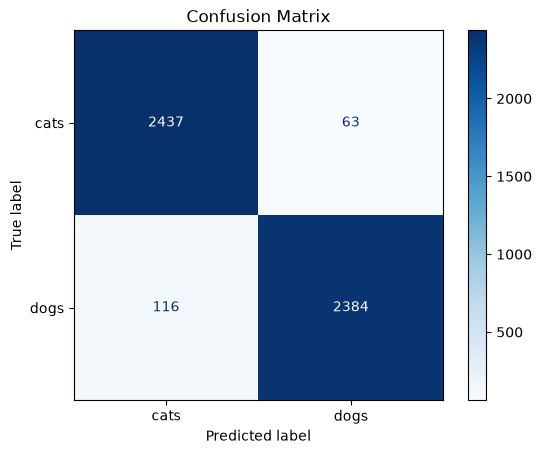

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()